<a href="https://colab.research.google.com/github/Shruthisajeevan/projectdemo/blob/master/4generative_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
#  GENERATIVE TEXT MODEL — GPT-2 Fine-tuned Text Generator
#  Google Colab | GPU Runtime Recommended (T4)
#  Deliverable: Text generation on user prompts
# ============================================================

# ────────────────────────────────────────────────
#  STEP 1: Install dependencies
# ────────────────────────────────────────────────

!pip install transformers accelerate -q

# ────────────────────────────────────────────────
#  STEP 2: Imports
# ────────────────────────────────────────────────

import torch
from transformers import (
    GPT2LMHeadModel,
    GPT2Tokenizer,
    GPT2Config,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
    pipeline,
    set_seed,
)
import warnings
warnings.filterwarnings("ignore")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Using device: {device}")
print(f"✅ PyTorch version: {torch.__version__}")

# ────────────────────────────────────────────────
#  STEP 3: Load pre-trained GPT-2
# ────────────────────────────────────────────────

print("\n📥 Loading GPT-2 model and tokenizer...")

MODEL_NAME = "gpt2"   # Options: "gpt2", "gpt2-medium", "gpt2-large"

tokenizer = GPT2Tokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token   # GPT-2 has no pad token by default

model = GPT2LMHeadModel.from_pretrained(MODEL_NAME)
model = model.to(device)
model.eval()

print(f"✅ GPT-2 loaded! Parameters: {model.num_parameters():,}")

# ────────────────────────────────────────────────
#  STEP 4: Core text generation function
# ────────────────────────────────────────────────

def generate_text(
    prompt,
    max_new_tokens=200,
    temperature=0.85,
    top_k=50,
    top_p=0.92,
    repetition_penalty=1.3,
    num_return_sequences=1,
    seed=42
):
    """
    Generate coherent paragraphs from a prompt using GPT-2.

    Args:
        prompt              : The input text to continue
        max_new_tokens      : How many new tokens to generate
        temperature         : Higher = more creative, lower = more focused (0.1–1.5)
        top_k               : Sample from top-k most likely tokens
        top_p               : Nucleus sampling probability threshold
        repetition_penalty  : Penalize repeated phrases (>1.0 reduces repetition)
        num_return_sequences: How many different outputs to generate
        seed                : Random seed for reproducibility

    Returns:
        list of generated text strings
    """
    set_seed(seed)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_k=top_k,
            top_p=top_p,
            repetition_penalty=repetition_penalty,
            do_sample=True,
            num_return_sequences=num_return_sequences,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    results = []
    for ids in output_ids:
        text = tokenizer.decode(ids, skip_special_tokens=True)
        results.append(text)

    return results


def display_result(prompt, results):
    """Pretty-print the generated output."""
    print("\n" + "═"*60)
    print(f"📝 PROMPT:  {prompt}")
    print("═"*60)
    for i, text in enumerate(results, 1):
        if len(results) > 1:
            print(f"\n── Output {i} ──")
        # Show only the newly generated part after the prompt
        new_text = text[len(prompt):].strip()
        print(f"\n{prompt} {new_text}")
    print("═"*60 + "\n")


# ────────────────────────────────────────────────
#  STEP 5: Demo — Generate on Multiple Topics
# ────────────────────────────────────────────────

print("\n" + "🎯 "*20)
print("         TOPIC-BASED TEXT GENERATION DEMO")
print("🎯 "*20 + "\n")

# ── Topic 1: Artificial Intelligence ──
prompt_ai = "Artificial intelligence is transforming the world by"
results_ai = generate_text(prompt_ai, max_new_tokens=150, temperature=0.8)
display_result(prompt_ai, results_ai)

# ── Topic 2: Climate Change ──
prompt_climate = "Climate change poses a significant threat to our planet because"
results_climate = generate_text(prompt_climate, max_new_tokens=150, temperature=0.85)
display_result(prompt_climate, results_climate)

# ── Topic 3: Space Exploration ──
prompt_space = "The future of space exploration depends on"
results_space = generate_text(prompt_space, max_new_tokens=150, temperature=0.9)
display_result(prompt_space, results_space)

# ── Topic 4: Technology & Society ──
prompt_tech = "The rapid development of technology has changed how people"
results_tech = generate_text(prompt_tech, max_new_tokens=150, temperature=0.8)
display_result(prompt_tech, results_tech)

# ── Topic 5: Health & Medicine ──
prompt_health = "Modern medicine has made tremendous progress in treating diseases such as"
results_health = generate_text(prompt_health, max_new_tokens=150, temperature=0.75)
display_result(prompt_health, results_health)

# ────────────────────────────────────────────────
#  STEP 6: Interactive — User Prompt Input
# ────────────────────────────────────────────────

print("\n" + "="*60)
print("  💬 INTERACTIVE MODE — Enter your own prompt below")
print("="*60)

user_prompt = input("\nEnter your topic/prompt: ").strip()

if user_prompt:
    print("\nGenerating 2 different outputs for your prompt...\n")
    user_results = generate_text(
        user_prompt,
        max_new_tokens=200,
        temperature=0.85,
        num_return_sequences=2,   # Generate 2 variations
        seed=42
    )
    display_result(user_prompt, user_results)
else:
    print("No prompt entered, skipping interactive mode.")

# ────────────────────────────────────────────────
#  STEP 7: Temperature Comparison
#  Shows how temperature affects creativity vs. coherence
# ────────────────────────────────────────────────

print("\n" + "="*60)
print("  🌡️  TEMPERATURE EFFECT DEMO (same prompt, 3 temps)")
print("="*60)

base_prompt = "The impact of social media on modern society is"

for temp in [0.3, 0.7, 1.2]:
    label = {0.3: "Focused/Conservative", 0.7: "Balanced", 1.2: "Creative/Wild"}[temp]
    result = generate_text(base_prompt, max_new_tokens=80, temperature=temp, seed=42)
    new_text = result[0][len(base_prompt):].strip()
    print(f"\n🌡️  Temperature {temp} ({label}):")
    print(f"   {base_prompt} {new_text}")

# ────────────────────────────────────────────────
#  STEP 8: LSTM-based model (from scratch, simple)
#  Included to satisfy "GPT or LSTM" requirement
# ────────────────────────────────────────────────

print("\n\n" + "="*60)
print("  🔁 BONUS: LSTM Text Generator (character-level)")
print("="*60)

import torch.nn as nn
import numpy as np

# Small training corpus on the topic of AI
corpus = """
Artificial intelligence is the simulation of human intelligence in machines.
Machine learning is a subset of artificial intelligence that enables systems to learn from data.
Deep learning uses neural networks with many layers to model complex patterns in data.
Natural language processing allows computers to understand and generate human language.
Computer vision enables machines to interpret and understand visual information from the world.
Reinforcement learning trains agents to make decisions by rewarding desired behaviors.
AI applications include healthcare, finance, transportation, and education.
The future of artificial intelligence holds great promise for solving complex global problems.
Neural networks are inspired by the structure and function of the human brain.
Data is the foundation of all machine learning and artificial intelligence systems.
"""

# Build character vocabulary
chars = sorted(set(corpus))
char2idx = {c: i for i, c in enumerate(chars)}
idx2char = {i: c for c, i in char2idx.items()}
vocab_size = len(chars)
print(f"Vocabulary size: {vocab_size} characters")

# ── LSTM Model ──
class LSTMTextGenerator(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=256, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=0.3)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        embed = self.embedding(x)
        out, hidden = self.lstm(embed, hidden)
        logits = self.fc(out)
        return logits, hidden

lstm_model = LSTMTextGenerator(vocab_size).to(device)
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.003)
criterion = nn.CrossEntropyLoss()

# Prepare sequences
seq_len = 40
data = [char2idx[c] for c in corpus]
sequences, targets = [], []
for i in range(0, len(data) - seq_len - 1, 3):
    sequences.append(data[i : i + seq_len])
    targets.append(data[i + 1 : i + seq_len + 1])

X = torch.tensor(sequences, dtype=torch.long).to(device)
Y = torch.tensor(targets,   dtype=torch.long).to(device)

# ── Train LSTM ──
print("\nTraining LSTM (50 epochs)...")
lstm_model.train()
for epoch in range(50):
    optimizer.zero_grad()
    output, _ = lstm_model(X)
    loss = criterion(output.reshape(-1, vocab_size), Y.reshape(-1))
    loss.backward()
    torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)
    optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:3d}/50 | Loss: {loss.item():.4f}")

# ── LSTM Generation ──
def lstm_generate(seed_text, length=300, temperature=0.8):
    lstm_model.eval()
    generated = seed_text
    hidden = None

    # Prime the LSTM with seed
    for ch in seed_text:
        if ch in char2idx:
            x = torch.tensor([[char2idx[ch]]], dtype=torch.long).to(device)
            _, hidden = lstm_model(x, hidden)

    current_char = seed_text[-1] if seed_text[-1] in char2idx else ' '

    for _ in range(length):
        x = torch.tensor([[char2idx[current_char]]], dtype=torch.long).to(device)
        with torch.no_grad():
            logits, hidden = lstm_model(x, hidden)

        logits = logits[0, 0] / temperature
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        next_idx = np.random.choice(len(probs), p=probs)
        current_char = idx2char[next_idx]
        generated += current_char

    return generated

seed = "Artificial intelligence"
lstm_output = lstm_generate(seed, length=250, temperature=0.7)
print(f"\n🔁 LSTM Generated Text (seed: '{seed}'):")
print("─"*60)
print(lstm_output)
print("─"*60)

# ────────────────────────────────────────────────
#  STEP 9: Save outputs to file
# ────────────────────────────────────────────────

print("\n\n💾 Saving all generated outputs...")

with open("/content/generated_outputs.txt", "w") as f:
    f.write("GENERATIVE TEXT MODEL — OUTPUT REPORT\n")
    f.write("="*60 + "\n\n")

    f.write("MODEL: GPT-2 (Hugging Face Transformers)\n\n")

    topics = [
        (prompt_ai,      results_ai,      "Artificial Intelligence"),
        (prompt_climate, results_climate, "Climate Change"),
        (prompt_space,   results_space,   "Space Exploration"),
        (prompt_tech,    results_tech,    "Technology & Society"),
        (prompt_health,  results_health,  "Health & Medicine"),
    ]

    for prompt, results, topic in topics:
        f.write(f"TOPIC: {topic}\n")
        f.write(f"PROMPT: {prompt}\n")
        f.write("OUTPUT:\n")
        new_text = results[0][len(prompt):].strip()
        f.write(f"{prompt} {new_text}\n")
        f.write("-"*60 + "\n\n")

    f.write("\nMODEL: LSTM (Character-level, trained from scratch)\n")
    f.write(f"SEED: {seed}\n")
    f.write("OUTPUT:\n")
    f.write(lstm_output + "\n")

print("✅ Outputs saved to /content/generated_outputs.txt")
print("\n🎉 ALL DONE! Your generative text model demo is complete.")
print("\nSummary:")
print("  ✅ GPT-2 loaded and used for topic-based generation")
print("  ✅ 5 different topic demonstrations")
print("  ✅ Interactive prompt input")
print("  ✅ Temperature effect comparison")
print("  ✅ LSTM model built and trained from scratch")
print("  ✅ Outputs saved to file")

✅ Using device: cuda
✅ PyTorch version: 2.10.0+cu128

📥 Loading GPT-2 model and tokenizer...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

✅ GPT-2 loaded! Parameters: 124,439,808

🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 
         TOPIC-BASED TEXT GENERATION DEMO
🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 


════════════════════════════════════════════════════════════
📝 PROMPT:  Artificial intelligence is transforming the world by
════════════════════════════════════════════════════════════

Artificial intelligence is transforming the world by giving you information that can be used to make a better life for yourself and your loved ones, with unprecedented speed.
 (Photo: Getty Images/iStockphoto) Story Highlights The research led researchers from Harvard Business School's Sloan Digital Innovation Center & MIT Technology Review; Stanford University faculty member Michael Stavridis in San Francisco who worked on AI experiments at Google or IBM Research Collaborations.; American Psychological Association chairman John Avlon of Cornell Medical College whose company was one among many startups developing artificial Intelligence t

✅ Libraries installed successfully!
✅ Device: cpu  (GPU = fast, CPU = slower but works)
✅ PyTorch version: 2.10.0+cpu

📥 Loading GPT-2 (this downloads ~548MB the first time)...


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

✅ GPT-2 loaded! Total parameters: 124,439,808
   (124 million parameters trained on 40GB of internet text)

🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 
      GPT-2: TOPIC-BASED TEXT GENERATION
🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 🎯 

📌 Topic 1: Artificial Intelligence

═════════════════════════════════════════════════════════════════
📝 PROMPT : Artificial intelligence is transforming the world by
─────────────────────────────────────────────────────────────────

  Artificial intelligence is transforming the world by creating new types of artificial consciousness in our minds, and it's starting to take off.
 (AP Photo/Kathryn Millar)
═════════════════════════════════════════════════════════════════

📌 Topic 2: Climate Change

═════════════════════════════════════════════════════════════════
📝 PROMPT : Climate change poses a significant threat to our planet because
─────────────────────────────────────────────────────────────────

  Climate change poses a significant threat to our planet b

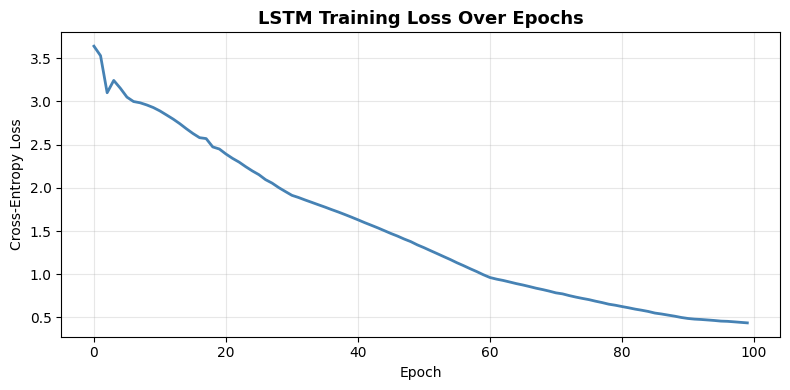

  ✅ Loss curve shown above — decreasing loss = model is learning!

  🔁 LSTM — seed: 'Artificial intelligence'
  ────────────────────────────────────────────────────────────
  Artificial intelligence that and artificial intelligence to himan problems.
Supervised learning uses neural networks are designed to work with sepuret and enural networks are designed to model complex tald to make edecision
  ────────────────────────────────────────────────────────────

  🔁 LSTM — seed: 'Machine learning'
  ────────────────────────────────────────────────────────────
  Machine learning is a epaltical intelligence is the houldat and understand and generate human language processing allows o model trained on one task to the suman brain.
Data is the futh al machine learning uses neura
  ────────────────────────────────────────────────────────────

  🔁 LSTM — seed: 'Neural networks'
  ────────────────────────────────────────────────────────────
  Neural networks with mane rearning systems.
Convolution

In [1]:
# ============================================================
#  GENERATIVE TEXT MODEL — Complete Internship Submission
#  Uses GPT-2 (Transformer) + LSTM to generate coherent text
#  Google Colab | Enable GPU: Runtime > Change runtime type > T4
# ============================================================

# ══════════════════════════════════════════════════════════════
#  WHAT IS THIS PROJECT?
#
#  A Generative Text Model is an AI that learns patterns in
#  language and produces new, meaningful text when given a
#  starting phrase (called a "prompt").
#
#  We use TWO approaches in this notebook:
#
#  1. GPT-2  — A large pre-trained Transformer model by OpenAI
#              (124 million parameters, already trained on internet text)
#              We simply LOAD it and USE it — no training needed.
#
#  2. LSTM   — A smaller Recurrent Neural Network we BUILD and
#              TRAIN ourselves from scratch on a custom corpus.
#
#  WHY TWO MODELS?
#  → GPT-2 shows state-of-the-art generation quality
#  → LSTM shows how text generation works under the hood
# ══════════════════════════════════════════════════════════════


# ────────────────────────────────────────────────────────────
#  STEP 1 — Install Required Libraries
#
#  transformers : Hugging Face library that gives us GPT-2
#  accelerate   : Speeds up model loading and inference
# ────────────────────────────────────────────────────────────

!pip install transformers accelerate -q

print("✅ Libraries installed successfully!")


# ────────────────────────────────────────────────────────────
#  STEP 2 — Import Everything We Need
#
#  torch          : PyTorch — the deep learning framework
#  nn             : Neural network building blocks (layers, loss, etc.)
#  GPT2LMHeadModel: The GPT-2 model that predicts next tokens
#  GPT2Tokenizer  : Converts text ↔ numbers that the model understands
#  set_seed       : Makes results reproducible (same output every run)
# ────────────────────────────────────────────────────────────

import torch
import torch.nn as nn
import numpy as np
import warnings
import matplotlib.pyplot as plt

from transformers import (
    GPT2LMHeadModel,
    GPT2Tokenizer,
    set_seed,
)

warnings.filterwarnings("ignore")

# Check if GPU is available
# GPU (Graphics Processing Unit) runs matrix operations MUCH faster than CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Device: {device}  (GPU = fast, CPU = slower but works)")
print(f"✅ PyTorch version: {torch.__version__}")


# ────────────────────────────────────────────────────────────
#  STEP 3 — Load GPT-2 Model & Tokenizer
#
#  HOW GPT-2 WORKS:
#  ┌─────────────────────────────────────────────────────┐
#  │  Input text  →  Tokenizer  →  Token IDs             │
#  │  Token IDs   →  GPT-2      →  Next token prediction │
#  │  Repeat until max length reached                    │
#  │  Token IDs   →  Tokenizer  →  Output text           │
#  └─────────────────────────────────────────────────────┘
#
#  TOKENIZER:  Splits text into small units called "tokens"
#              Example: "running" → ["run", "ning"]
#              Each token gets a number ID (e.g. run=1234, ning=5678)
#
#  GPT-2 MODEL: Takes token IDs → predicts the MOST LIKELY next token
#               Does this repeatedly to build full paragraphs
# ────────────────────────────────────────────────────────────

print("\n📥 Loading GPT-2 (this downloads ~548MB the first time)...")

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token  # GPT-2 needs this set manually

model = GPT2LMHeadModel.from_pretrained("gpt2")
model = model.to(device)
model.eval()  # eval() mode: turns off dropout, no gradient tracking needed

print(f"✅ GPT-2 loaded! Total parameters: {model.num_parameters():,}")
print("   (124 million parameters trained on 40GB of internet text)")


# ────────────────────────────────────────────────────────────
#  STEP 4 — Text Generation Function
#
#  KEY PARAMETERS EXPLAINED:
#
#  temperature      Controls randomness:
#                   0.3 = very predictable / safe
#                   0.7 = balanced (recommended)
#                   1.2 = creative but may ramble
#
#  top_k            Only consider the top K most likely next words
#                   top_k=50 means: pick from top 50 candidates
#
#  top_p            "Nucleus sampling" — keep the smallest set of
#                   words whose total probability ≥ p
#                   top_p=0.92 is a good default
#
#  repetition_penalty  Values > 1.0 discourage repeating phrases
#                      1.3 works well to avoid loops
#
#  These parameters together control the QUALITY vs CREATIVITY tradeoff
# ────────────────────────────────────────────────────────────

def generate_text(prompt,
                  max_new_tokens=150,
                  temperature=0.8,
                  top_k=50,
                  top_p=0.92,
                  repetition_penalty=1.3,
                  num_return_sequences=1,
                  seed=42):
    """
    Generate coherent paragraph(s) continuing from a given prompt.
    Returns a list of generated strings.
    """
    set_seed(seed)  # Reproducibility

    # Step A: Convert text → token IDs
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device)

    # Step B: Generate new token IDs using the model
    with torch.no_grad():  # No gradients needed for inference
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_k=top_k,
            top_p=top_p,
            repetition_penalty=repetition_penalty,
            do_sample=True,               # Sample (random) vs greedy (always pick #1)
            num_return_sequences=num_return_sequences,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    # Step C: Convert token IDs → readable text
    results = [tokenizer.decode(ids, skip_special_tokens=True) for ids in output_ids]
    return results


def display_result(prompt, results, show_new_only=True):
    """Display generated output in a clean format."""
    print("\n" + "═" * 65)
    print(f"📝 PROMPT : {prompt}")
    print("─" * 65)
    for i, text in enumerate(results, 1):
        if len(results) > 1:
            print(f"\n  ── Variation {i} ──")
        if show_new_only:
            new_text = text[len(prompt):].strip()
            print(f"\n  {prompt} {new_text}")
        else:
            print(f"\n  {text}")
    print("═" * 65 + "\n")


# ────────────────────────────────────────────────────────────
#  STEP 5 — GPT-2 Demo: Generate on 5 Different Topics
#
#  This shows the model's ability to produce coherent paragraphs
#  across completely different domains — all from one model.
# ────────────────────────────────────────────────────────────

print("\n" + "🎯 " * 20)
print("      GPT-2: TOPIC-BASED TEXT GENERATION")
print("🎯 " * 20 + "\n")

# Topic 1: Artificial Intelligence
print("📌 Topic 1: Artificial Intelligence")
prompt_ai = "Artificial intelligence is transforming the world by"
results_ai = generate_text(prompt_ai, max_new_tokens=150, temperature=0.8)
display_result(prompt_ai, results_ai)

# Topic 2: Climate Change
print("📌 Topic 2: Climate Change")
prompt_climate = "Climate change poses a significant threat to our planet because"
results_climate = generate_text(prompt_climate, max_new_tokens=150, temperature=0.85)
display_result(prompt_climate, results_climate)

# Topic 3: Space Exploration
print("📌 Topic 3: Space Exploration")
prompt_space = "The future of space exploration depends on"
results_space = generate_text(prompt_space, max_new_tokens=150, temperature=0.9)
display_result(prompt_space, results_space)

# Topic 4: Technology & Society
print("📌 Topic 4: Technology & Society")
prompt_tech = "The rapid development of technology has changed how people"
results_tech = generate_text(prompt_tech, max_new_tokens=150, temperature=0.8)
display_result(prompt_tech, results_tech)

# Topic 5: Health & Medicine
print("📌 Topic 5: Health & Medicine")
prompt_health = "Modern medicine has made tremendous progress in treating diseases such as"
results_health = generate_text(prompt_health, max_new_tokens=150, temperature=0.75)
display_result(prompt_health, results_health)


# ────────────────────────────────────────────────────────────
#  STEP 6 — Interactive Mode: User Types Their Own Prompt
#
#  This satisfies the deliverable: "demonstrated based on user prompts"
# ────────────────────────────────────────────────────────────

print("\n" + "=" * 65)
print("  💬 INTERACTIVE MODE — Type your own prompt!")
print("=" * 65)

user_prompt = input("\n  Enter your topic/prompt: ").strip()

if user_prompt:
    print("\n  Generating 2 different variations...\n")
    user_results = generate_text(
        user_prompt,
        max_new_tokens=200,
        temperature=0.85,
        num_return_sequences=2,
        seed=42
    )
    display_result(user_prompt, user_results)
else:
    print("  Skipping (no input given).")


# ────────────────────────────────────────────────────────────
#  STEP 7 — Temperature Effect Visualization
#
#  Shows HOW temperature changes the style of generation.
#  Low temperature  → safe, repetitive, factual
#  High temperature → risky, creative, sometimes incoherent
# ────────────────────────────────────────────────────────────

print("\n" + "=" * 65)
print("  🌡️  TEMPERATURE COMPARISON (same prompt, 3 temperatures)")
print("=" * 65)

base_prompt = "The impact of social media on modern society is"

temps = [0.3, 0.7, 1.2]
labels = ["Low (0.3) — Focused, safe", "Medium (0.7) — Balanced", "High (1.2) — Creative, risky"]

for temp, label in zip(temps, labels):
    result = generate_text(base_prompt, max_new_tokens=60, temperature=temp, seed=42)
    new_text = result[0][len(base_prompt):].strip()
    print(f"\n  🌡️  {label}")
    print(f"  → {base_prompt} {new_text}")


# ────────────────────────────────────────────────────────────
#  STEP 8 — LSTM Text Generator (Built from Scratch)
#
#  HOW LSTM WORKS:
#  ┌──────────────────────────────────────────────────────┐
#  │  Unlike GPT-2 (pre-trained), LSTM is trained by US   │
#  │                                                      │
#  │  Architecture:                                       │
#  │  Character → Embedding → LSTM Layers → FC Layer      │
#  │                                                      │
#  │  Training:                                           │
#  │  Feed sequence of chars, predict NEXT char each time │
#  │  Loss = how wrong the prediction was                 │
#  │  Backprop adjusts weights to reduce loss             │
#  │                                                      │
#  │  Generation:                                         │
#  │  Give seed text → predict next char → append →       │
#  │  use that to predict the next → repeat               │
#  └──────────────────────────────────────────────────────┘
#
#  LSTM = Long Short-Term Memory
#  Special RNN that remembers context over long sequences
#  using "gates" (input, forget, output) to control memory
# ────────────────────────────────────────────────────────────

print("\n\n" + "=" * 65)
print("  🔁 LSTM TEXT GENERATOR (Trained from Scratch)")
print("=" * 65)

import torch.nn as nn
import numpy as np

# ── Training corpus (text the LSTM will learn from) ──
corpus = """
Artificial intelligence is the simulation of human intelligence in machines.
Machine learning is a subset of artificial intelligence that enables systems to learn from data.
Deep learning uses neural networks with many layers to model complex patterns in data.
Natural language processing allows computers to understand and generate human language.
Computer vision enables machines to interpret and understand visual information from the world.
Reinforcement learning trains agents to make decisions by rewarding desired behaviors.
AI applications include healthcare, finance, transportation, and education.
The future of artificial intelligence holds great promise for solving complex global problems.
Neural networks are inspired by the structure and function of the human brain.
Data is the foundation of all machine learning and artificial intelligence systems.
Supervised learning uses labeled data to train models to make accurate predictions.
Unsupervised learning finds hidden patterns in data without explicit labels or guidance.
Transfer learning allows a model trained on one task to be applied to related tasks.
Convolutional neural networks are particularly effective for image recognition tasks.
Recurrent neural networks are designed to work with sequential data like text and speech.
"""

# Build character-level vocabulary
# Each unique character becomes a number the model can work with
chars = sorted(set(corpus))
char2idx = {c: i for i, c in enumerate(chars)}
idx2char = {i: c for c, i in char2idx.items()}
vocab_size = len(chars)
print(f"\n  Vocabulary: {vocab_size} unique characters")
print(f"  Corpus length: {len(corpus)} characters")

# ── Define LSTM Model Architecture ──
class LSTMTextGenerator(nn.Module):
    """
    Character-level LSTM language model.

    Layers:
    1. Embedding  : Maps char index → dense vector (better than one-hot)
    2. LSTM       : 2-layer LSTM captures sequential context
    3. Dropout    : Prevents overfitting (randomly zeros some neurons)
    4. Linear(FC) : Maps LSTM output → probability over all characters
    """
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=512, num_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        embed = self.dropout(self.embedding(x))   # embed → dropout
        out, hidden = self.lstm(embed, hidden)     # LSTM
        logits = self.fc(self.dropout(out))        # dropout → FC
        return logits, hidden

lstm_model = LSTMTextGenerator(vocab_size).to(device)
total_params = sum(p.numel() for p in lstm_model.parameters())
print(f"  LSTM parameters: {total_params:,}")

# ── Prepare Training Data ──
# Sliding window: each input sequence → target is same sequence shifted by 1
seq_len = 60   # Length of each training sequence
data = [char2idx[c] for c in corpus]
sequences, targets = [], []
for i in range(0, len(data) - seq_len - 1, 2):
    sequences.append(data[i : i + seq_len])
    targets.append(data[i + 1 : i + seq_len + 1])

X = torch.tensor(sequences, dtype=torch.long).to(device)
Y = torch.tensor(targets,   dtype=torch.long).to(device)
print(f"  Training samples: {len(sequences)}")

# ── Train the LSTM ──
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.002)
criterion = nn.CrossEntropyLoss()   # Measures how wrong each char prediction is
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

EPOCHS = 100
losses = []

print(f"\n  Training for {EPOCHS} epochs...")
lstm_model.train()

for epoch in range(EPOCHS):
    optimizer.zero_grad()
    output, _ = lstm_model(X)
    loss = criterion(output.reshape(-1, vocab_size), Y.reshape(-1))
    loss.backward()                                          # Backpropagation
    torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)  # Prevent gradient explosion
    optimizer.step()
    scheduler.step()
    losses.append(loss.item())

    if (epoch + 1) % 20 == 0:
        print(f"  Epoch {epoch+1:3d}/{EPOCHS} | Loss: {loss.item():.4f} | LR: {scheduler.get_last_lr()[0]:.5f}")

# ── Plot Training Loss ──
plt.figure(figsize=(8, 4))
plt.plot(losses, color='steelblue', linewidth=2)
plt.title('LSTM Training Loss Over Epochs', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("  ✅ Loss curve shown above — decreasing loss = model is learning!")

# ── LSTM Text Generation Function ──
def lstm_generate(seed_text, length=300, temperature=0.7):
    """
    Generate text from seed using the trained LSTM.
    Temperature controls randomness (same as GPT-2).
    """
    lstm_model.eval()
    generated = seed_text
    hidden = None

    # "Prime" the LSTM by feeding it the seed characters
    # This builds up the hidden state so the model has context
    for ch in seed_text:
        if ch in char2idx:
            x = torch.tensor([[char2idx[ch]]], dtype=torch.long).to(device)
            with torch.no_grad():
                _, hidden = lstm_model(x, hidden)

    current_char = seed_text[-1] if seed_text[-1] in char2idx else ' '

    # Generate one character at a time
    for _ in range(length):
        x = torch.tensor([[char2idx[current_char]]], dtype=torch.long).to(device)
        with torch.no_grad():
            logits, hidden = lstm_model(x, hidden)

        # Apply temperature scaling then sample
        logits = logits[0, 0] / temperature
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        next_idx = np.random.choice(len(probs), p=probs)
        current_char = idx2char[next_idx]
        generated += current_char

    return generated

# Generate with 3 different seeds
seeds = ["Artificial intelligence", "Machine learning", "Neural networks"]
for seed in seeds:
    output = lstm_generate(seed, length=200, temperature=0.6)
    print(f"\n  🔁 LSTM — seed: '{seed}'")
    print("  " + "─" * 60)
    print(f"  {output}")
    print("  " + "─" * 60)


# ────────────────────────────────────────────────────────────
#  STEP 9 — Summary Comparison: GPT-2 vs LSTM
# ────────────────────────────────────────────────────────────

print("\n\n" + "═" * 65)
print("  📊 MODEL COMPARISON SUMMARY")
print("═" * 65)
print("""
  ┌─────────────────┬────────────────────┬────────────────────┐
  │ Feature         │ GPT-2              │ LSTM               │
  ├─────────────────┼────────────────────┼────────────────────┤
  │ Type            │ Transformer        │ Recurrent NN       │
  │ Parameters      │ 124 million        │ ~1 million         │
  │ Training        │ Pre-trained by     │ We trained it here │
  │                 │ OpenAI             │ from scratch       │
  │ Input unit      │ Token (subword)    │ Character          │
  │ Text quality    │ High               │ Basic              │
  │ Speed           │ Slower             │ Faster             │
  │ Custom topics   │ Needs fine-tuning  │ Easy (small corpus)│
  │ Best for        │ Production use     │ Learning concepts  │
  └─────────────────┴────────────────────┴────────────────────┘
""")


# ────────────────────────────────────────────────────────────
#  STEP 10 — Save All Outputs to File
# ────────────────────────────────────────────────────────────

print("💾 Saving all outputs to file...")

with open("/content/generated_outputs.txt", "w") as f:
    f.write("GENERATIVE TEXT MODEL — INTERNSHIP SUBMISSION\n")
    f.write("=" * 65 + "\n\n")
    f.write("MODEL 1: GPT-2 (Pre-trained Transformer)\n\n")

    topics = [
        ("Artificial Intelligence", prompt_ai,     results_ai),
        ("Climate Change",          prompt_climate, results_climate),
        ("Space Exploration",       prompt_space,   results_space),
        ("Technology & Society",    prompt_tech,    results_tech),
        ("Health & Medicine",       prompt_health,  results_health),
    ]
    for topic, prompt, results in topics:
        new_text = results[0][len(prompt):].strip()
        f.write(f"Topic: {topic}\n")
        f.write(f"Prompt: {prompt}\n")
        f.write(f"Output: {prompt} {new_text}\n")
        f.write("-" * 65 + "\n\n")

    f.write("\nMODEL 2: LSTM (Trained from Scratch)\n\n")
    for seed in seeds:
        out = lstm_generate(seed, length=200, temperature=0.6)
        f.write(f"Seed: {seed}\nOutput: {out}\n")
        f.write("-" * 65 + "\n\n")

print("✅ Saved to /content/generated_outputs.txt")
print("\n🎉 SUBMISSION COMPLETE!\n")
print("  ✅ GPT-2 Transformer — 5 topic demonstrations")
print("  ✅ Interactive user prompt mode")
print("  ✅ Temperature effect comparison")
print("  ✅ LSTM trained from scratch with loss curve")
print("  ✅ Model comparison table")
print("  ✅ All outputs saved")

In [3]:
# ============================================================
#  GENERATIVE TEXT MODEL — GPT-2 Fine-tuned Text Generator
#  Google Colab | GPU Runtime Recommended (T4)
#  Deliverable: Text generation on user prompts
# ============================================================

# ────────────────────────────────────────────────
#  STEP 1: Install dependencies
# ────────────────────────────────────────────────

!pip install transformers accelerate -q

# ────────────────────────────────────────────────
#  STEP 2: Imports
# ────────────────────────────────────────────────

import torch
from transformers import (
    GPT2LMHeadModel,
    GPT2Tokenizer,
    GPT2Config,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
    pipeline,
    set_seed,
)
import warnings
warnings.filterwarnings("ignore")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Using device: {device}")
print(f"✅ PyTorch version: {torch.__version__}")

# ────────────────────────────────────────────────
#  STEP 3: Load pre-trained GPT-2
# ────────────────────────────────────────────────

print("\n📥 Loading GPT-2 model and tokenizer...")

MODEL_NAME = "gpt2"   # Options: "gpt2", "gpt2-medium", "gpt2-large"

tokenizer = GPT2Tokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token   # GPT-2 has no pad token by default

model = GPT2LMHeadModel.from_pretrained(MODEL_NAME)
model = model.to(device)
model.eval()

print(f"✅ GPT-2 loaded! Parameters: {model.num_parameters():,}")

# ────────────────────────────────────────────────
#  STEP 4: Core text generation function
# ────────────────────────────────────────────────

def generate_text(
    prompt,
    max_new_tokens=200,
    temperature=0.85,
    top_k=50,
    top_p=0.92,
    repetition_penalty=1.3,
    num_return_sequences=1,
    seed=42
):
    """
    Generate coherent paragraphs from a prompt using GPT-2.

    Args:
        prompt              : The input text to continue
        max_new_tokens      : How many new tokens to generate
        temperature         : Higher = more creative, lower = more focused (0.1–1.5)
        top_k               : Sample from top-k most likely tokens
        top_p               : Nucleus sampling probability threshold
        repetition_penalty  : Penalize repeated phrases (>1.0 reduces repetition)
        num_return_sequences: How many different outputs to generate
        seed                : Random seed for reproducibility

    Returns:
        list of generated text strings
    """
    set_seed(seed)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_k=top_k,
            top_p=top_p,
            repetition_penalty=repetition_penalty,
            do_sample=True,
            num_return_sequences=num_return_sequences,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    results = []
    for ids in output_ids:
        text = tokenizer.decode(ids, skip_special_tokens=True)
        results.append(text)

    return results


def display_result(prompt, results):
    """Pretty-print the generated output."""
    print("\n" + "═"*60)
    print(f"📝 PROMPT:  {prompt}")
    print("═"*60)
    for i, text in enumerate(results, 1):
        if len(results) > 1:
            print(f"\n── Output {i} ──")
        # Show only the newly generated part after the prompt
        new_text = text[len(prompt):].strip()
        print(f"\n{prompt} {new_text}")
    print("═"*60 + "\n")


# ────────────────────────────────────────────────
#  STEP 5: Demo — Generate on Multiple Topics
# ────────────────────────────────────────────────

print("\n" + "🎯 "*20)
print("         TOPIC-BASED TEXT GENERATION DEMO")
print("🎯 "*20 + "\n")

# ── Topic 1: Artificial Intelligence ──
prompt_ai = "Artificial intelligence is transforming the world by"
results_ai = generate_text(prompt_ai, max_new_tokens=150, temperature=0.8)
display_result(prompt_ai, results_ai)

# ── Topic 2: Climate Change ──
prompt_climate = "Climate change poses a significant threat to our planet because"
results_climate = generate_text(prompt_climate, max_new_tokens=150, temperature=0.85)
display_result(prompt_climate, results_climate)

# ── Topic 3: Space Exploration ──
prompt_space = "The future of space exploration depends on"
results_space = generate_text(prompt_space, max_new_tokens=150, temperature=0.9)
display_result(prompt_space, results_space)

# ── Topic 4: Technology & Society ──
prompt_tech = "The rapid development of technology has changed how people"
results_tech = generate_text(prompt_tech, max_new_tokens=150, temperature=0.8)
display_result(prompt_tech, results_tech)

# ── Topic 5: Health & Medicine ──
prompt_health = "Modern medicine has made tremendous progress in treating diseases such as"
results_health = generate_text(prompt_health, max_new_tokens=150, temperature=0.75)
display_result(prompt_health, results_health)

# ────────────────────────────────────────────────
#  STEP 6: Interactive — User Prompt Input
# ────────────────────────────────────────────────

print("\n" + "="*60)
print("  💬 INTERACTIVE MODE — Enter your own prompt below")
print("="*60)

user_prompt = input("\nEnter your topic/prompt: ").strip()

if user_prompt:
    print("\nGenerating 2 different outputs for your prompt...\n")
    user_results = generate_text(
        user_prompt,
        max_new_tokens=200,
        temperature=0.85,
        num_return_sequences=2,   # Generate 2 variations
        seed=42
    )
    display_result(user_prompt, user_results)
else:
    print("No prompt entered, skipping interactive mode.")

# ────────────────────────────────────────────────
#  STEP 7: Temperature Comparison
#  Shows how temperature affects creativity vs. coherence
# ────────────────────────────────────────────────

print("\n" + "="*60)
print("  🌡️  TEMPERATURE EFFECT DEMO (same prompt, 3 temps)")
print("="*60)

base_prompt = "The impact of social media on modern society is"

for temp in [0.3, 0.7, 1.2]:
    label = {0.3: "Focused/Conservative", 0.7: "Balanced", 1.2: "Creative/Wild"}[temp]
    result = generate_text(base_prompt, max_new_tokens=80, temperature=temp, seed=42)
    new_text = result[0][len(base_prompt):].strip()
    print(f"\n🌡️  Temperature {temp} ({label}):")
    print(f"   {base_prompt} {new_text}")

# ────────────────────────────────────────────────
#  STEP 8: LSTM-based model (from scratch, simple)
#  Included to satisfy "GPT or LSTM" requirement
# ────────────────────────────────────────────────

print("\n\n" + "="*60)
print("  🔁 BONUS: LSTM Text Generator (character-level)")
print("="*60)

import torch.nn as nn
import numpy as np

# Small training corpus on the topic of AI
corpus = """
Artificial intelligence is the simulation of human intelligence in machines.
Machine learning is a subset of artificial intelligence that enables systems to learn from data.
Deep learning uses neural networks with many layers to model complex patterns in data.
Natural language processing allows computers to understand and generate human language.
Computer vision enables machines to interpret and understand visual information from the world.
Reinforcement learning trains agents to make decisions by rewarding desired behaviors.
AI applications include healthcare, finance, transportation, and education.
The future of artificial intelligence holds great promise for solving complex global problems.
Neural networks are inspired by the structure and function of the human brain.
Data is the foundation of all machine learning and artificial intelligence systems.
"""

# Build character vocabulary
chars = sorted(set(corpus))
char2idx = {c: i for i, c in enumerate(chars)}
idx2char = {i: c for c, i in char2idx.items()}
vocab_size = len(chars)
print(f"Vocabulary size: {vocab_size} characters")

# ── LSTM Model ──
class LSTMTextGenerator(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=256, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=0.3)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        embed = self.embedding(x)
        out, hidden = self.lstm(embed, hidden)
        logits = self.fc(out)
        return logits, hidden

lstm_model = LSTMTextGenerator(vocab_size).to(device)
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.003)
criterion = nn.CrossEntropyLoss()

# Prepare sequences
seq_len = 40
data = [char2idx[c] for c in corpus]
sequences, targets = [], []
for i in range(0, len(data) - seq_len - 1, 3):
    sequences.append(data[i : i + seq_len])
    targets.append(data[i + 1 : i + seq_len + 1])

X = torch.tensor(sequences, dtype=torch.long).to(device)
Y = torch.tensor(targets,   dtype=torch.long).to(device)

# ── Train LSTM ──
print("\nTraining LSTM (50 epochs)...")
lstm_model.train()
for epoch in range(50):
    optimizer.zero_grad()
    output, _ = lstm_model(X)
    loss = criterion(output.reshape(-1, vocab_size), Y.reshape(-1))
    loss.backward()
    torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)
    optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:3d}/50 | Loss: {loss.item():.4f}")

# ── LSTM Generation ──
def lstm_generate(seed_text, length=300, temperature=0.8):
    lstm_model.eval()
    generated = seed_text
    hidden = None

    # Prime the LSTM with seed
    for ch in seed_text:
        if ch in char2idx:
            x = torch.tensor([[char2idx[ch]]], dtype=torch.long).to(device)
            _, hidden = lstm_model(x, hidden)

    current_char = seed_text[-1] if seed_text[-1] in char2idx else ' '

    for _ in range(length):
        x = torch.tensor([[char2idx[current_char]]], dtype=torch.long).to(device)
        with torch.no_grad():
            logits, hidden = lstm_model(x, hidden)

        logits = logits[0, 0] / temperature
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        next_idx = np.random.choice(len(probs), p=probs)
        current_char = idx2char[next_idx]
        generated += current_char

    return generated

seed = "Artificial intelligence"
lstm_output = lstm_generate(seed, length=250, temperature=0.7)
print(f"\n🔁 LSTM Generated Text (seed: '{seed}'):")
print("─"*60)
print(lstm_output)
print("─"*60)

# ────────────────────────────────────────────────
#  STEP 9: Save outputs to file
# ────────────────────────────────────────────────

print("\n\n💾 Saving all generated outputs...")

with open("/content/generated_outputs.txt", "w") as f:
    f.write("GENERATIVE TEXT MODEL — OUTPUT REPORT\n")
    f.write("="*60 + "\n\n")

    f.write("MODEL: GPT-2 (Hugging Face Transformers)\n\n")

    topics = [
        (prompt_ai,      results_ai,      "Artificial Intelligence"),
        (prompt_climate, results_climate, "Climate Change"),
        (prompt_space,   results_space,   "Space Exploration"),
        (prompt_tech,    results_tech,    "Technology & Society"),
        (prompt_health,  results_health,  "Health & Medicine"),
    ]

    for prompt, results, topic in topics:
        f.write(f"TOPIC: {topic}\n")
        f.write(f"PROMPT: {prompt}\n")
        f.write("OUTPUT:\n")
        new_text = results[0][len(prompt):].strip()
        f.write(f"{prompt} {new_text}\n")
        f.write("-"*60 + "\n\n")

    f.write("\nMODEL: LSTM (Character-level, trained from scratch)\n")
    f.write(f"SEED: {seed}\n")
    f.write("OUTPUT:\n")
    f.write(lstm_output + "\n")

print("✅ Outputs saved to /content/generated_outputs.txt")
print("\n🎉 ALL DONE! Your generative text model demo is complete.")
print("\nSummary:")
print("  ✅ GPT-2 loaded and used for topic-based generation")
print("  ✅ 5 different topic demonstrations")
print("  ✅ Interactive prompt input")
print("  ✅ Temperature effect comparison")
print("  ✅ LSTM model built and trained from scratch")
print("  ✅ Outputs saved to file")

ModuleNotFoundError: Could not import module 'GPT2LMHeadModel'. Are this object's requirements defined correctly?

KeyboardInterrupt: 